Epoch 0, Loss: 21.026722
Epoch 1000, Loss: 0.051203
Epoch 2000, Loss: 0.006071
Epoch 3000, Loss: 0.005443
Epoch 4000, Loss: 0.001205
Epoch 5000, Loss: 0.001088
Epoch 6000, Loss: 0.000848
Epoch 7000, Loss: 0.000627
Epoch 8000, Loss: 0.000759
Epoch 9000, Loss: 0.000517


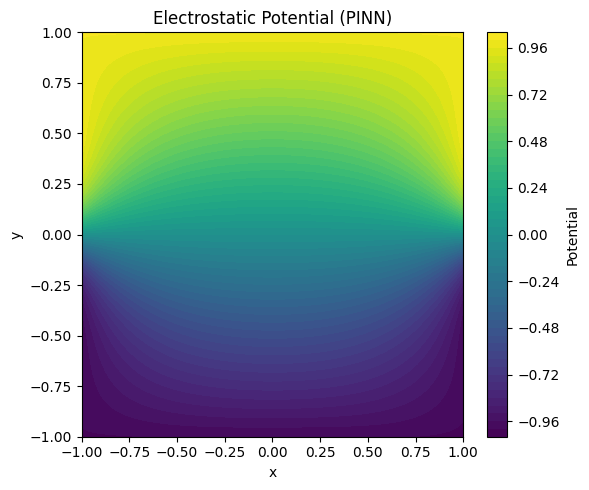

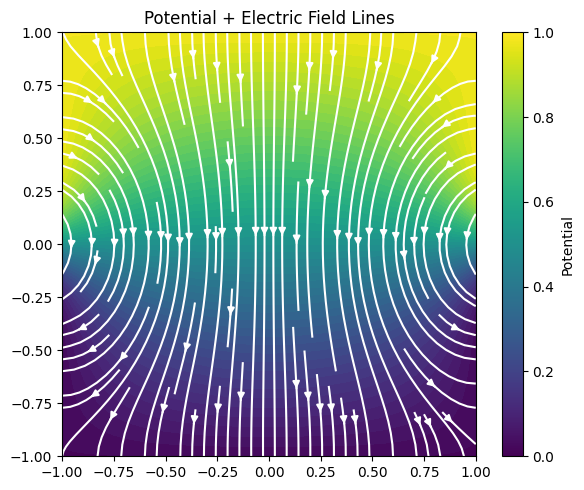

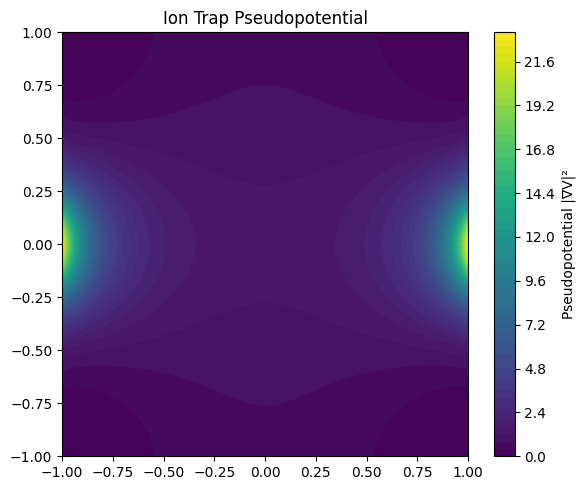

In [9]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Setup
# ---------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# ---------------------------
# PINN Model
# ---------------------------
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 128), nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PINN().to(device)

# ---------------------------
# Sampling
# ---------------------------
def sample_interior(n=5000):
    x = torch.rand(n,1)*1.8 - 0.9
    y = torch.rand(n,1)*1.8 - 0.9
    return torch.cat([x,y], dim=1).to(device)

def sample_boundary(n=2000):
    n_side = n // 4

    # Left
    y = torch.rand(n_side,1)*2 - 1
    x = -torch.ones_like(y)
    left = torch.cat([x,y], dim=1)

    # Right
    y = torch.rand(n_side,1)*2 - 1
    x = torch.ones_like(y)
    right = torch.cat([x,y], dim=1)

    # Bottom
    x = torch.rand(n_side,1)*2 - 1
    y = -torch.ones_like(x)
    bottom = torch.cat([x,y], dim=1)

    # Top
    x = torch.rand(n_side,1)*2 - 1
    y = torch.ones_like(x)
    top = torch.cat([x,y], dim=1)

    return torch.cat([left,right,bottom,top], dim=0).to(device)

# ---------------------------
# Boundary Conditions
# --------------------------
def boundary_condition(xy):
    y = xy[:,1:2]

    # smooth transition
    return torch.tanh(5 * y)

# ---------------------------
# Loss Function
# ---------------------------
def loss_fn(epoch):
    xy = sample_interior()
    xy.requires_grad_(True)

    V = model(xy)

    grads = torch.autograd.grad(V, xy, torch.ones_like(V), create_graph=True)[0]
    Vx = grads[:,0:1]
    Vy = grads[:,1:2]

    Vxx = torch.autograd.grad(Vx, xy, torch.ones_like(Vx), create_graph=True)[0][:,0:1]
    Vyy = torch.autograd.grad(Vy, xy, torch.ones_like(Vy), create_graph=True)[0][:,1:2]

    pde_loss = (Vxx + Vyy).pow(2).mean()

    xb = sample_boundary()
    Vb = model(xb)
    target = boundary_condition(xb)

    bc_loss = (Vb - target).pow(2).mean()

    if epoch < 3000:
        bc_weight = 20
    else:
        bc_weight = 5

    return pde_loss + bc_weight * bc_loss

# ---------------------------
# Training
# ---------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3000, gamma=0.5)

for epoch in range(10000):
    optimizer.zero_grad()
    loss = loss_fn(epoch)
    loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# ---------------------------
# Evaluation Grid
# ---------------------------
grid_size = 150
x = np.linspace(-1,1,grid_size)
y = np.linspace(-1,1,grid_size)
X, Y = np.meshgrid(x,y)

xy = torch.tensor(np.vstack([X.ravel(), Y.ravel()]).T,
                  dtype=torch.float32).to(device)
xy.requires_grad_(True)

V = model(xy)

grads = torch.autograd.grad(V, xy, torch.ones_like(V), create_graph=True)[0]
Vx = grads[:,0]
Vy = grads[:,1]

# Electric field
Ex = -Vx.detach().cpu().numpy().reshape(grid_size,grid_size)
Ey = -Vy.detach().cpu().numpy().reshape(grid_size,grid_size)

# Potential
V_plot = V.detach().cpu().numpy().reshape(grid_size,grid_size)

# Pseudopotential
psi = (Vx**2 + Vy**2).detach().cpu().numpy().reshape(grid_size,grid_size)

# ---------------------------
# Visualization
# ---------------------------

# 1. Potential
plt.figure(figsize=(6,5))
plt.contourf(X, Y, V_plot, levels=60)
plt.colorbar(label="Potential")
plt.title("Electrostatic Potential (PINN)")
plt.xlabel("x"); plt.ylabel("y")
plt.tight_layout()
plt.show()

# 2. Electric Field Lines
plt.figure(figsize=(6,5))
plt.contourf(X, Y, V_plot, levels=60)
plt.streamplot(X, Y, Ex, Ey, color='white', density=1.2)
plt.colorbar(label="Potential")
plt.title("Potential + Electric Field Lines")
plt.tight_layout()
plt.show()

# 3. Pseudopotential
plt.figure(figsize=(6,5))
plt.contourf(X, Y, psi, levels=60)
plt.colorbar(label="Pseudopotential |\u2207V|\u00b2")
plt.title("Ion Trap Pseudopotential")
plt.tight_layout()
plt.show()